In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [118]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    LabelEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [5]:
df=pd.read_excel("/content/Final BI.xlsx")
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,...,Fuel_Cost,Expected_Delivery_Time,delay_time,delivery_status,Fuel_per_min,Extra_Cost,Speed Per Area,Delay_Positive,Extra_Fuel,Estimated_Traffic
0,bivf289084020,38,4.8,12.978453,77.643685,12.998453,77.663685,"Thursday, March 13, 2025",08:20:00,08:30:00,...,0.03,12.40,127.60,Delayed,0.00625,0.9570,15,127.60,0.79750,High
1,bnwh475156832,21,4.8,23.355164,85.324097,23.365164,85.334097,"Friday, March 7, 2025",08:35:00,08:45:00,...,0.03,6.04,88.96,Delayed,0.00625,0.6672,15,88.96,0.55600,High
2,bqif031216711,35,4.8,22.745536,75.893106,22.805536,75.953106,"Wednesday, March 5, 2025",22:45:00,22:55:00,...,0.03,36.24,58.76,Delayed,0.00625,0.4407,15,58.76,0.36725,High
3,bsqd094342021,32,4.8,23.218998,77.373573,23.248998,77.403573,"Monday, February 17, 2025",22:50:00,23:00:00,...,0.03,18.08,96.92,Delayed,0.00625,0.7269,15,96.92,0.60575,High
4,bttb175409775,25,4.8,21.175975,72.795503,21.185975,72.805503,"Saturday, March 15, 2025",09:30:00,09:40:00,...,0.03,6.08,83.92,Delayed,0.00625,0.6294,15,83.92,0.52450,High


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40046 entries, 0 to 40045
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 40046 non-null  object 
 1   Agent_Age                40046 non-null  int64  
 2   Agent_Rating             40046 non-null  float64
 3   Store_Latitude           40046 non-null  float64
 4   Store_Longitude          40046 non-null  float64
 5   Drop_Latitude            40046 non-null  float64
 6   Drop_Longitude           40046 non-null  float64
 7   Order_Date               40046 non-null  object 
 8   Order_Time               40046 non-null  object 
 9   Pickup_Time              40046 non-null  object 
 10  Weather                  40046 non-null  object 
 11  Traffic                  40046 non-null  object 
 12  Vehicle                  40046 non-null  object 
 13  Area                     40046 non-null  object 
 14  Delivery_Time         

In [9]:
df.shape

(40046, 29)

In [10]:
df.columns

Index(['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude',
       'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date',
       'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area',
       'Delivery_Time', 'Category', 'PrepTime_Min', 'Distance_KM',
       'fuel_consumption_per_km', 'Fuel_Cost', 'Expected_Delivery_Time',
       'delay_time', 'delivery_status', 'Fuel_per_min', 'Extra_Cost',
       'Speed Per Area', 'Delay_Positive', 'Extra_Fuel', 'Estimated_Traffic'],
      dtype='object')

In [11]:
df.isnull().sum()

,0
Order_ID,0
Agent_Age,0
Agent_Rating,0
Store_Latitude,0
Store_Longitude,0
Drop_Latitude,0
Drop_Longitude,0
Order_Date,0
Order_Time,0
Pickup_Time,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Vehicle"].value_counts()

,count
Vehicle,
motorcycle,23464
scooter,13374
van,3200
bicycle,8


<Axes: xlabel='Estimated_Traffic', ylabel='count'>

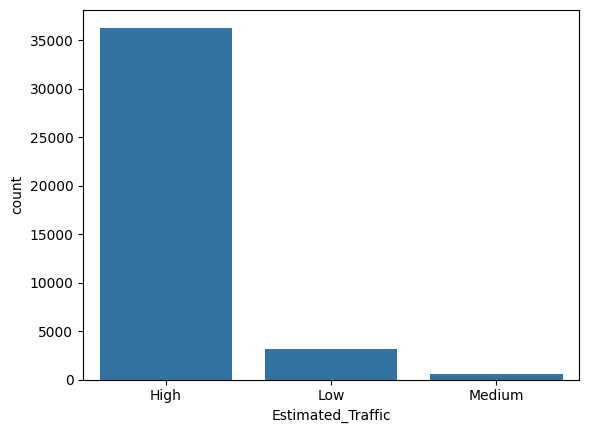

In [14]:
sns.countplot(df, x="Estimated_Traffic")

In [16]:
df.dtypes

,0
Order_ID,object
Agent_Age,int64
Agent_Rating,float64
Store_Latitude,float64
Store_Longitude,float64
Drop_Latitude,float64
Drop_Longitude,float64
Order_Date,datetime64[ns]
Order_Time,datetime64[ns]
Pickup_Time,datetime64[ns]


In [17]:
df['Day'] = df['Order_Date'].dt.day_name()
df['Month'] = df['Order_Date'].dt.month
df['Hour'] = df['Order_Time'].dt.hour

In [18]:
df['delivery_status'].value_counts()

,count
delivery_status,
Delayed,38232
Delivered,1814


In [19]:
avg_delivery = df['Delivery_Time'].mean()
avg_delivery

np.float64(125.090620786096)

The average delivery time is approximately 125 minutes, which indicates a significant delay in the delivery process and highlights inefficiencies in operations

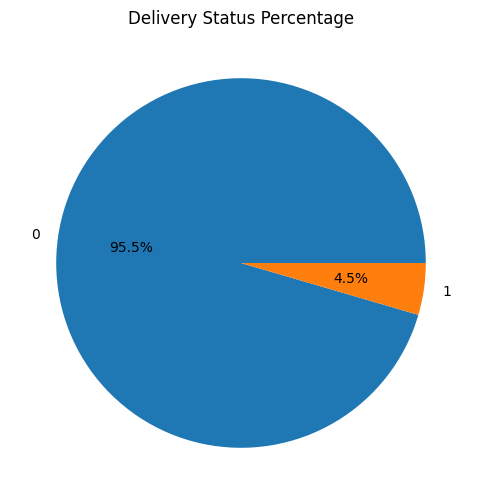

In [117]:
delivery_counts = df['delivery_status'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    delivery_counts,
    labels=delivery_counts.index,
    autopct='%1.1f%%'
)

plt.title("Delivery Status Percentage")

plt.show()

In [20]:
df.groupby(pd.cut(df['Distance_KM'], bins=5))['Delivery_Time'].mean()

/tmp/ipykernel_11019/3287699409.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Distance_KM'], bins=5))['Delivery_Time'].mean()


,Delivery_Time
Distance_KM,
"(1.441, 5.356]",105.541400
"(5.356, 9.252]",116.128564
"(9.252, 13.148]",137.576905
"(13.148, 17.044]",142.143859
"(17.044, 20.94]",142.358547


"The increase becomes less significant after 13 km, indicating possible saturation due to traffic or operational limits."

In [21]:
df.groupby('Estimated_Traffic')['Delivery_Time'].mean()

,Delivery_Time
Estimated_Traffic,
High,131.468979
Low,56.985211
Medium,96.676580


Moving from Low to Jam traffic increases delivery time by ~45 minutes

In [22]:
df.groupby('Area')['Delivery_Time'].mean().sort_values()

,Delivery_Time
Area,
Other,104.501908
Urban,109.636917
Metropolitian,129.860602
Semi-Urban,238.717391


 Delivery time in Semi-Urban areas is more than double Urban areas.

Delivery time increases by more than 50 minutes during peak evening hours

In [23]:
df['diff'] = df['Delivery_Time'] - df['Expected_Delivery_Time']
df['diff'].mean()

np.float64(88.98346688807871)

On average, deliveries are delayed by approximately 89 minutes beyond the expected time

In [24]:
df['Delivery_Time'].describe()

,Delivery_Time
count,40046.000000
mean,125.090621
std,51.929145
min,10.000000
25%,90.000000
50%,125.000000
75%,160.000000
max,270.000000


In [25]:
total_distance = df['Distance_KM'].sum()
total_distance

np.float64(388492.42)

In [26]:
# Best day (lowest delivery time)
best_day = df.groupby('Day')['Delivery_Time'].mean().sort_values()

# Best hour
best_hour = df.groupby('Hour')['Delivery_Time'].mean().sort_values()

best_day, best_hour

(Day
 Monday       120.405546
 Saturday     120.895311
 Wednesday    124.463520
 Friday       124.665874
 Thursday     125.346168
 Tuesday      127.033568
 Sunday       131.821548
 Name: Delivery_Time, dtype: float64,
 Hour
 9      92.610829
 10     93.112769
 8      93.134811
 0     102.756345
 23    107.300317
 16    109.692068
 15    109.813836
 22    110.748559
 11    125.597984
 12    129.034188
 14    129.576224
 18    129.591827
 17    130.144135
 13    131.836850
 21    146.388007
 19    147.120152
 20    148.663378
 Name: Delivery_Time, dtype: float64)

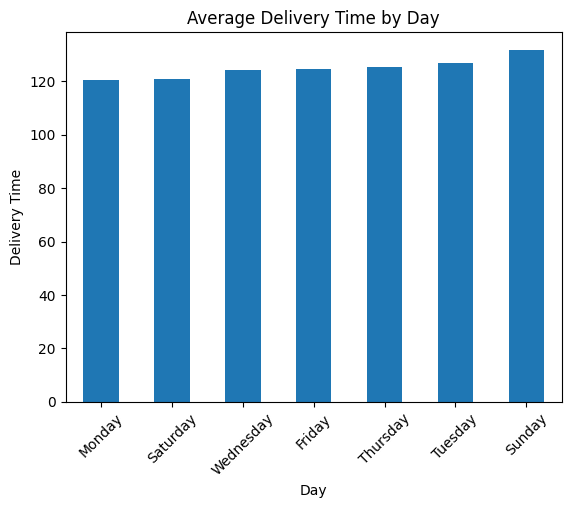

In [27]:
# Group by Day and calculate average delivery time
best_day = df.groupby('Day')['Delivery_Time'].mean().sort_values()

# Plot
plt.figure()
best_day.plot(kind='bar')

plt.title("Average Delivery Time by Day")
plt.xlabel("Day")
plt.ylabel("Delivery Time")
plt.xticks(rotation=45)
plt.show()

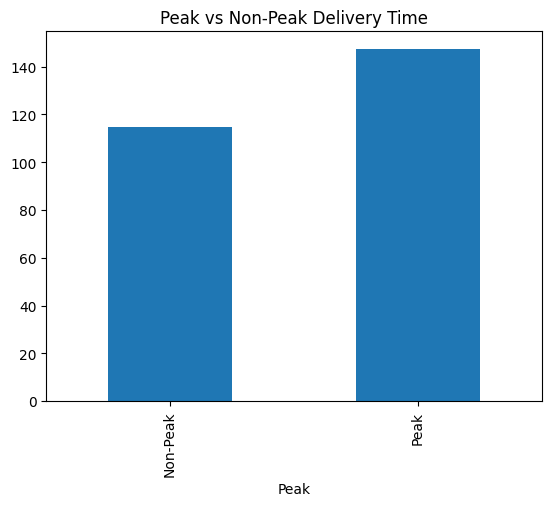

In [28]:
# Create peak column
df['Peak'] = df['Hour'].apply(lambda x: 'Peak' if 19 <= x <= 21 else 'Non-Peak')

# Compare
peak_analysis = df.groupby('Peak')['Delivery_Time'].mean()

peak_analysis.plot(kind='bar')

plt.title("Peak vs Non-Peak Delivery Time")
plt.show()

In [29]:
best_time = best_hour.idxmin()
worst_time = best_hour.idxmax()

best_time, worst_time

(np.int32(9), np.int32(20))

In [30]:
total_extra_cost = df['Extra_Cost'].sum()
total_extra_cost

np.float64(33071.95)

"The total extra cost is approximately 33,071.95, indicating significant financial losses due to inefficiencies such as delays, traffic congestion, and suboptimal routing."

In [31]:
df.groupby('Estimated_Traffic')['Extra_Cost'].mean()

,Extra_Cost
Estimated_Traffic,
High,0.839694
Low,0.655919
Medium,0.894682


In [32]:
total_fuel = df['Fuel_Cost'].sum()
total_fuel

np.float64(1327.2266666666674)

"Fuel cost increases with distance, indicating a direct relationship between logistics operations and expenses

In [33]:
traffic_rate = df['Estimated_Traffic'].value_counts(normalize=True)
traffic_rate

,proportion
Estimated_Traffic,
High,0.907207
Low,0.079359
Medium,0.013435


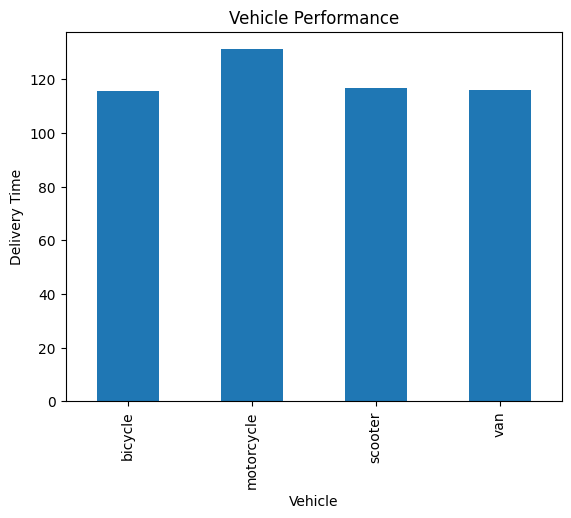

In [34]:
df.groupby('Vehicle')['Delivery_Time'].mean().plot(kind='bar')
plt.title("Vehicle Performance")
plt.ylabel("Delivery Time")
plt.show()

A high percentage of high traffic conditions explains increased delays in delivery

In [35]:
avg_delay = df['delay_time'].mean()
avg_delay

np.float64(88.98346688807871)

Higher delay time reflects poor delivery performance and inefficiencies in operations

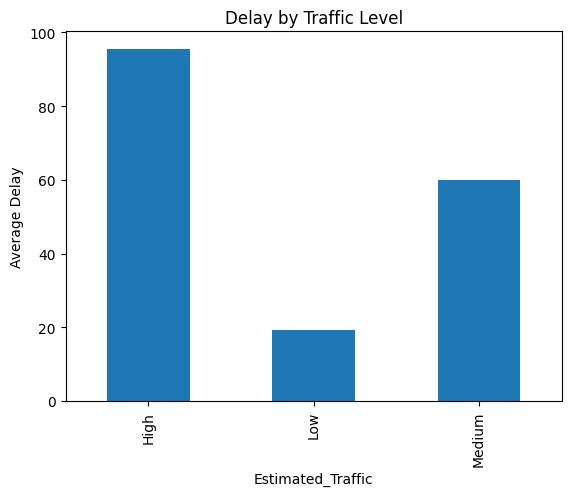

In [36]:
df.groupby('Estimated_Traffic')['delay_time'].mean().plot(kind='bar')
plt.title("Delay by Traffic Level")
plt.ylabel("Average Delay")
plt.show()

In [37]:
# Calculate CO2 emissions
df['CO2'] = df['Fuel_Cost'] * 2.31

# Total CO2
total_co2 = df['CO2'].sum()
total_co2

np.float64(3065.8936000000012)

In [38]:
df['CO2_per_order'] = df['Fuel_Cost'] * 2.31
df['CO2_per_order'].head()
#Calculates CO2 emissions for each delivery based on fuel cost.

,CO2_per_order
0,0.0693
1,0.0693
2,0.0693
3,0.0693
4,0.0693


In [39]:
# Calculate CO2 per kilometer
df['CO2_per_km'] = df['CO2_per_order'] / df['Distance_KM']

df['CO2_per_km'].head()

#Higher CO2 per kilometer indicates inefficient routes or high fuel consumption."

,CO2_per_km
0,0.022355
1,0.045894
2,0.007649
3,0.015332
4,0.045592


In [40]:
df.groupby('Hour')['CO2_per_order'].mean()

,CO2_per_order
Hour,
0,0.078114
8,0.078043
9,0.075949
10,0.075455
11,0.076371
12,0.076652
13,0.074433
14,0.076817
15,0.076777


In [41]:
df['CO2_per_min'] = df['CO2_per_order'] / df['Delivery_Time'].replace(0, 1)

In [42]:
df[['CO2_per_order','CO2_per_km','CO2_per_min']].head()

,CO2_per_order,CO2_per_km,CO2_per_min
0,0.0693,0.022355,0.000495
1,0.0693,0.045894,0.000729
2,0.0693,0.007649,0.000729
3,0.0693,0.015332,0.000603
4,0.0693,0.045592,0.000770


In [43]:
df.groupby('Estimated_Traffic')['CO2_per_order'].mean()
#Compares emissions across traffic conditions

,CO2_per_order
Estimated_Traffic,
High,0.076511
Low,0.077526
Medium,0.074123


In [44]:
df.groupby('Area')['CO2_per_order'].mean()

,CO2_per_order
Area,
Metropolitian,0.076575
Other,0.075479
Semi-Urban,0.071643
Urban,0.076712


Higher CO2 emissions indicate inefficient delivery operations and higher environmental impact

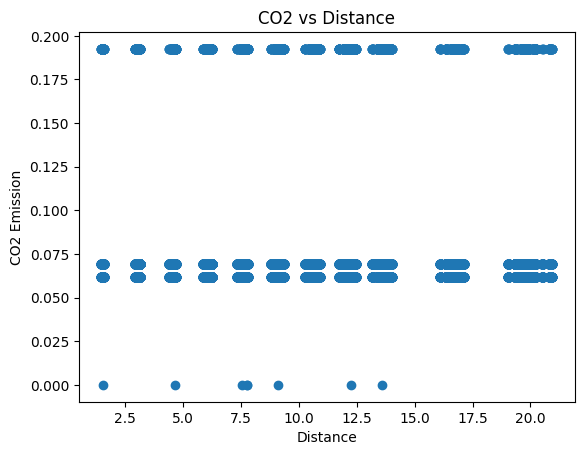

In [45]:
plt.scatter(df['Distance_KM'], df['CO2'])
plt.xlabel("Distance")
plt.ylabel("CO2 Emission")
plt.title("CO2 vs Distance")
plt.show()

In [46]:
# Average delivery time per vehicle per area
best_vehicle = df.groupby(['Area','Vehicle'])['Delivery_Time'].mean().reset_index()

best_vehicle

,Area,Vehicle,Delivery_Time
0,Metropolitian,bicycle,115.625000
1,Metropolitian,motorcycle,135.332679
2,Metropolitian,scooter,122.125730
3,Metropolitian,van,120.640252
4,Other,motorcycle,109.259325
5,Other,scooter,98.017199
6,Other,van,104.000000
7,Semi-Urban,motorcycle,238.782946
8,Semi-Urban,scooter,234.166667
9,Semi-Urban,van,245.000000


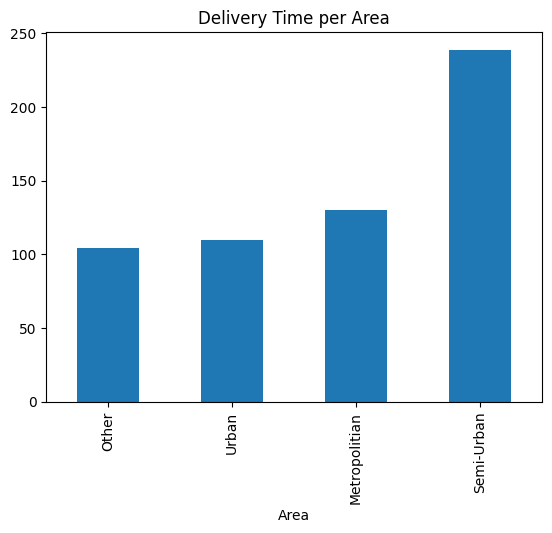

In [47]:
df.groupby('Area')['Delivery_Time'].mean().sort_values().plot(kind='bar')
plt.title("Delivery Time per Area")
plt.show()

In [48]:
# Unique stores
stores = df[['Store_Latitude','Store_Longitude']].drop_duplicates().shape[0]

# Unique drop locations
drops = df[['Drop_Latitude','Drop_Longitude']].drop_duplicates().shape[0]

stores, drops

(388, 4353)

In [49]:
# Delivery time by weather
weather_effect = df.groupby('Weather')['Delivery_Time'].mean()

weather_effect

,Delivery_Time
Weather,
Cloudy,138.325944
Fog,136.805064
Sandstorms,123.303969
Stormy,123.438212
Sunny,103.882380
Windy,123.971165


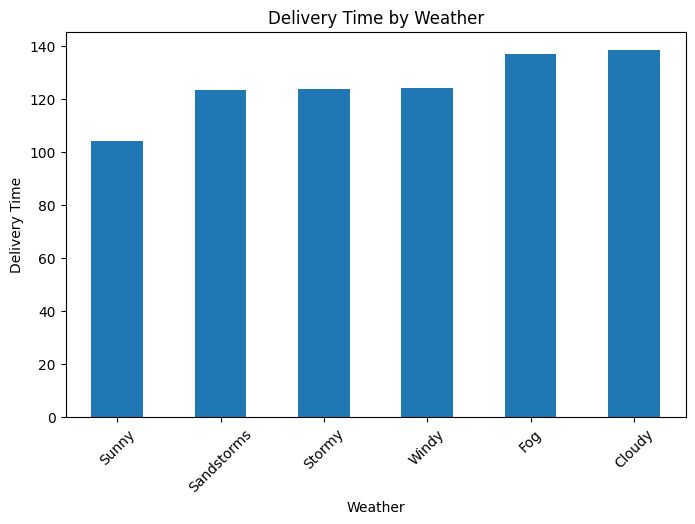

In [50]:
# Average delivery time by weather
weather_effect = df.groupby('Weather')['Delivery_Time'].mean().sort_values()

# Plot
plt.figure(figsize=(8,5))
weather_effect.plot(kind='bar')

plt.title("Delivery Time by Weather")
plt.ylabel("Delivery Time")
plt.xticks(rotation=45)
plt.show()

In [51]:
df.dtypes

,0
Order_ID,object
Agent_Age,int64
Agent_Rating,float64
Store_Latitude,float64
Store_Longitude,float64
Drop_Latitude,float64
Drop_Longitude,float64
Order_Date,datetime64[ns]
Order_Time,datetime64[ns]
Pickup_Time,datetime64[ns]


In [87]:
# =========================================================
# FEATURE ENGINEERING
# =========================================================

"""
Feature Engineering helps improve model performance
by creating new meaningful features from existing data.
"""

# ---------------------------------------------------------
# COMBINE CATEGORICAL FEATURES
# ---------------------------------------------------------

# Traffic + Weather
if 'Traffic' in df.columns and 'Weather' in df.columns:
    df['Traffic_Weather'] = (
        df['Traffic'].astype(str) + "_" +
        df['Weather'].astype(str)
    )

# Vehicle + Area
if 'Vehicle' in df.columns and 'Area' in df.columns:
    df['Vehicle_Area'] = (
        df['Vehicle'].astype(str) + "_" +
        df['Area'].astype(str)
    )

# Category + Weather
if 'Category' in df.columns and 'Weather' in df.columns:
    df['Category_Weather'] = (
        df['Category'].astype(str) + "_" +
        df['Weather'].astype(str)
    )

# ---------------------------------------------------------
# CREATE NUMERICAL FEATURES
# ---------------------------------------------------------

# Cost per KM
if 'Delivery_Cost' in df.columns and 'Distance_km' in df.columns:

    df['Cost_per_KM'] = (
        df['Delivery_Cost'] /
        (df['Distance_km'] + 1)
    )

# CO2 per KM
if 'CO2_Emission' in df.columns and 'Distance_km' in df.columns:

    df['CO2_per_KM'] = (
        df['CO2_Emission'] /
        (df['Distance_km'] + 1)
    )

# Speed Estimate
if 'Distance_km' in df.columns and 'Delivery_Time' in df.columns:

    df['Estimated_Speed'] = (
        df['Distance_km'] /
        (df['Delivery_Time'] + 1)
    )

print("Feature Engineering Completed Successfully")

Feature Engineering Completed Successfully


In [91]:

# KEEP ONLY IMPORTANT FEATURES
# =========================================================

"""
This step keeps the engineered features and removes
unnecessary columns to simplify the dataset and heatmap.
"""

# List of important columns to keep

selected_columns = [

    # Original Important Features
    'Traffic',
    'Weather',
    'Vehicle',
    'Area',
    'Delivery_Time',
    'Distance_km',
    'CO2_Emission',

    # Engineered Features
    'Traffic_Weather',
    'Vehicle_Area',
    'Cost_per_KM',
    'CO2_per_KM',
    'Estimated_Speed',

    # Target Column
    'delivery_status'
]

# Keep only existing columns
selected_columns = [
    col for col in selected_columns
    if col in df.columns
]

# Update dataframe
df = df[selected_columns]

print("Remaining Columns:")
print(df.columns)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(
    include=['object']
).columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(
        df[col].astype(str)
    )

print("Categorical Columns Encoded Successfully")

Remaining Columns:
Index(['Traffic', 'Weather', 'Vehicle', 'Area', 'Delivery_Time',
       'Traffic_Weather', 'Vehicle_Area', 'delivery_status'],
      dtype='object')
Categorical Columns Encoded Successfully


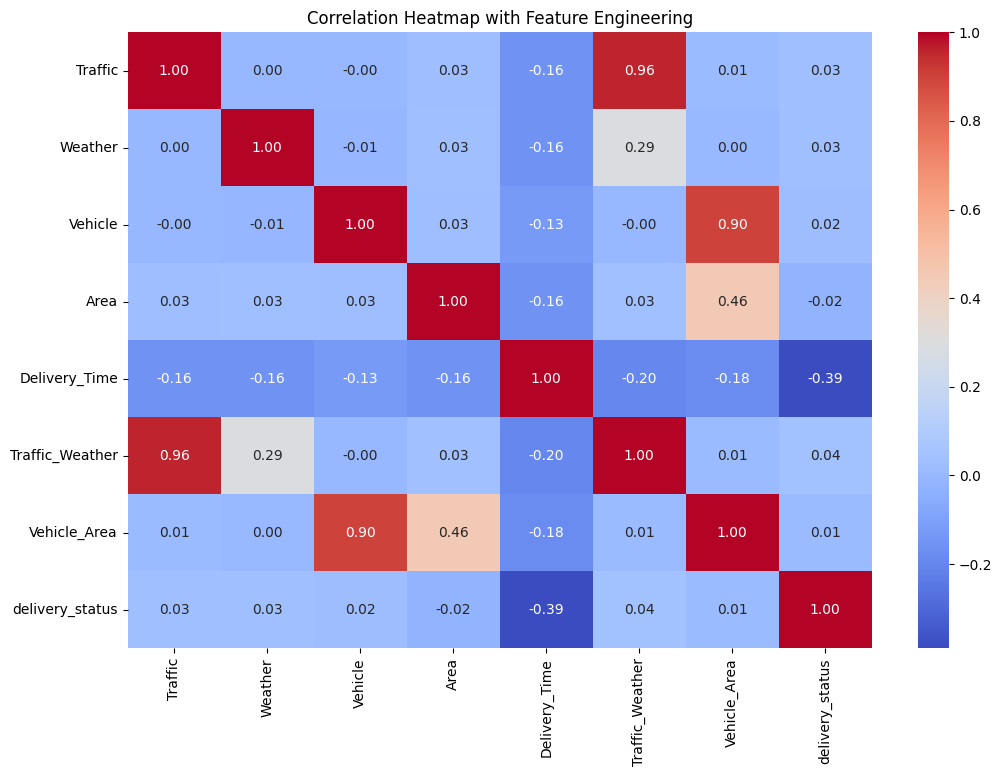

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap with Feature Engineering")

plt.show()

In [93]:
# =========================================================
# HANDLE DATETIME COLUMNS
# =========================================================

# Convert datetime columns into numerical features

datetime_columns = df.select_dtypes(
    include=['datetime64']
).columns

for col in datetime_columns:

    df[col] = pd.to_datetime(df[col])

    df[col + '_year'] = df[col].dt.year
    df[col + '_month'] = df[col].dt.month
    df[col + '_day'] = df[col].dt.day
    df[col + '_hour'] = df[col].dt.hour

# Drop original datetime columns
df.drop(columns=datetime_columns, inplace=True)

In [94]:
label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(
    include=['object']
).columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

In [96]:
X = df.drop('delivery_status', axis=1)
y = df['delivery_status']

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [98]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [99]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [100]:

lr_pred = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)

In [101]:

print("\n=================================================")
print("LOGISTIC REGRESSION")
print("=================================================")

print("Accuracy:", lr_accuracy)


LOGISTIC REGRESSION
Accuracy: 0.9685393258426966


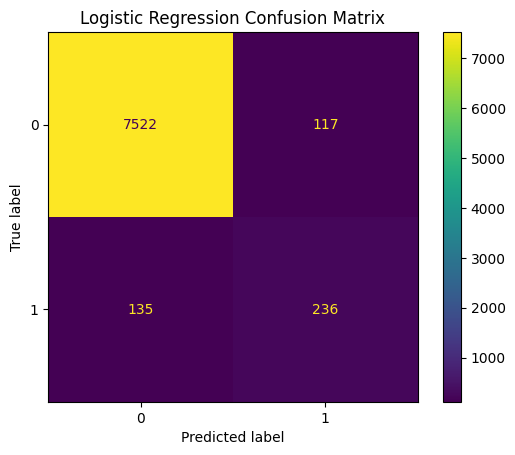

In [103]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test_scaled,
    y_test
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()


In [104]:

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)
print("\n=================================================")
print("DECISION TREE")
print("=================================================")

print("Accuracy:", dt_accuracy)



DECISION TREE
Accuracy: 0.9767790262172285


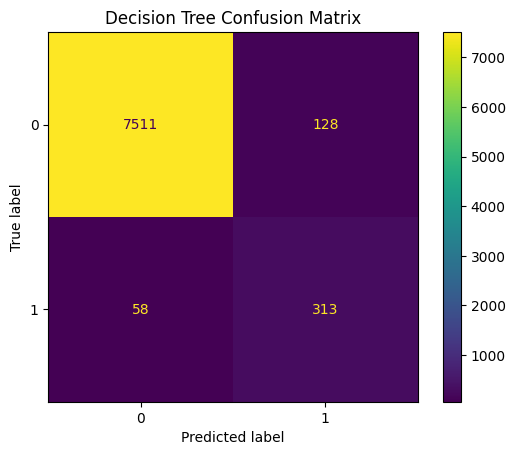

In [105]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    dt_model,
    X_test,
    y_test
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [106]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("\n=================================================")
print("RANDOM FOREST")
print("=================================================")

print("Accuracy:", rf_accuracy)



RANDOM FOREST
Accuracy: 0.9756554307116105



Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7639
           1       0.74      0.73      0.73       371

    accuracy                           0.98      8010
   macro avg       0.86      0.86      0.86      8010
weighted avg       0.98      0.98      0.98      8010



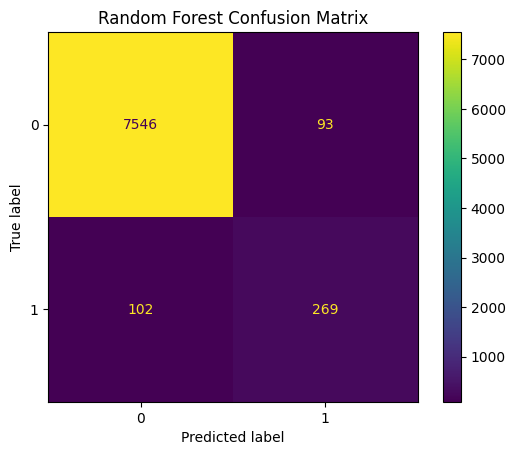

In [107]:
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()


FEATURE IMPORTANCE
           Feature  Importance
4    Delivery_Time    0.866366
5  Traffic_Weather    0.045426
1          Weather    0.024526
0          Traffic    0.022515
6     Vehicle_Area    0.016811
3             Area    0.015761
2          Vehicle    0.008594


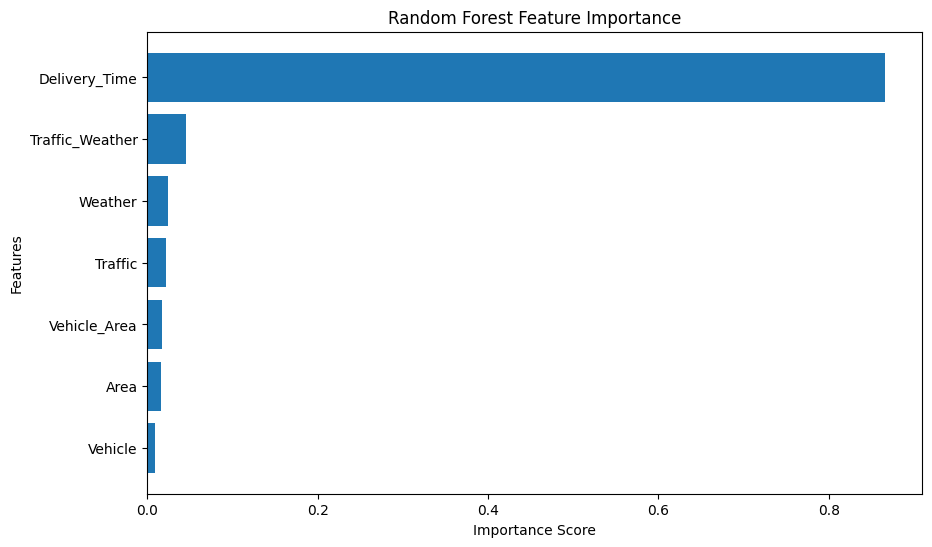

In [121]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n=================================================")
print("FEATURE IMPORTANCE")
print("=================================================")

print(feature_importance)

# Feature Importance Plot
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()


KNN
Accuracy: 0.9739076154806492

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      7639
           1       0.73      0.69      0.71       371

    accuracy                           0.97      8010
   macro avg       0.86      0.84      0.85      8010
weighted avg       0.97      0.97      0.97      8010



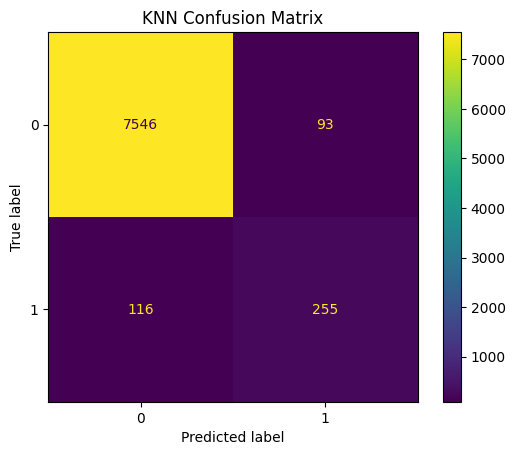

In [109]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("\n=================================================")
print("KNN")
print("=================================================")

print("Accuracy:", knn_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    knn_model,
    X_test_scaled,
    y_test
)

plt.title("KNN Confusion Matrix")
plt.show()

In [110]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy
    ]
})

print("\n=================================================")
print("MODEL COMPARISON")
print("=================================================")

print(comparison)


MODEL COMPARISON
                 Model  Accuracy
0  Logistic Regression  0.968539
1        Decision Tree  0.976779
2        Random Forest  0.975655
3                  KNN  0.973908


In [112]:
best_model = comparison.loc[
    comparison['Accuracy'].idxmax()
]

print("\n=================================================")
print("BEST MODEL")
print("=================================================")

print(
    f"The best model is {best_model['Model']} "
    f"with accuracy = {best_model['Accuracy']:.4f}"
)



BEST MODEL
The best model is Decision Tree with accuracy = 0.9768
